# Análise Exploratória: O "Declínio" do Gênero Romance

**Responsável**: Gabriel Costa Morais

**Pergunta Central**: O gênero Romance está morrendo?

____________________________________________________________________________________________________________________________________________________________

## 🎯 Motivação e Hipóteses

Existe uma noção relativamente difundida entre críticos, cineastas e parte do público de que o romance perdeu espaço no cinema comercial. Mediante isso, a análise exploratória a seguir tenta demonstrar/entender o motivo pelo qual a audiência está tendo percepção da queda dos filmes com gênero Romance.

Para esta análise, duas hipóteses foram avaliadas:
1. Quantos filmes de romance estavam sendo lançados por ano? (Análise de 1990 á 2025)
2. Quantos porcento dos filmes lançados em cada ano eram do gênero Romance? 

**Aviso**: Para esta análise foi utilizada única e exclusivamente a API da **The Movie Database (TMDB)**

**Link para acesso a API**: https://www.themoviedb.org/settings/api

____________________________________________________________________________________________________

# Primeira hipótese: Quantos filmes de romance estavam sendo lançados por ano? (1990-2025)

In [1]:
import requests

In [2]:
api_key = "05104af8d20b422ff0ef87262b056aa8"

url = "https://api.themoviedb.org/3/movie/popular"

parametros = {
    "api_key": api_key,
    "language": "pt-BR"
}

resposta = requests.get(url, params=parametros)

print(resposta.status_code)

200


In [5]:
url_generos = "https://api.themoviedb.org/3/genre/movie/list"

resposta_generos = requests.get(
    url_generos,
    params=parametros
)

print(resposta_generos.status_code)

200


In [6]:
generos = resposta_generos.json()["genres"]

for genero in generos:
    print(genero["id"], "-", genero["name"])

28 - Ação
12 - Aventura
16 - Animação
35 - Comédia
80 - Crime
99 - Documentário
18 - Drama
10751 - Família
14 - Fantasia
36 - História
27 - Terror
10402 - Música
9648 - Mistério
10749 - Romance
878 - Ficção científica
10770 - Cinema TV
53 - Thriller
10752 - Guerra
37 - Faroeste


In [7]:
url_discover = "https://api.themoviedb.org/3/discover/movie"

parametros_romance = {
    "api_key": api_key,
    "language": "pt-BR",
    "with_genres": 10749,
    "primary_release_date.gte": "1990-01-01",
    "primary_release_date.lte": "2025-12-31",
    "sort_by": "primary_release_date.asc",
    "page": 1
}

resposta_romance = requests.get(
    url_discover,
    params=parametros_romance
)

print(resposta_romance.status_code)

200


In [8]:
dados_romance = resposta_romance.json()

print(dados_romance["total_results"])

41428


In [ ]:
import requests
import pandas as pd
import time

# URL da API para descobrir filmes
url_discover = "https://api.themoviedb.org/3/discover/movie"

# Parâmetros da busca
parametros_romance = {
    "api_key": api_key,
    "language": "pt-BR",
    "with_genres": 10749,
    "primary_release_date.gte": "1990-01-01",
    "primary_release_date.lte": "2025-12-31",
    "sort_by": "primary_release_date.asc",
    "page": 1
}

# Lista onde vamos guardar os filmes
todos_filmes = []

# Primeiro fazemos uma requisição para descobrir
# quantas páginas existem
resposta = requests.get(
    url_discover,
    params=parametros_romance
)

# Transformamos a resposta em JSON
dados = resposta.json()

# Descobrimos o número total de páginas
total_paginas = dados["total_pages"]

print("Total de filmes encontrados:", dados["total_results"])
print("Total de páginas disponíveis:", total_paginas)

# Limite de páginas que vamos coletar
# A API pode ter muitas páginas, então vamos limitar
# para evitar uma quantidade excessiva de requisições
limite_paginas = min(total_paginas, 500)

print("Páginas que serão coletadas:", limite_paginas)

# percorrer as páginas
for pagina in range(1, limite_paginas + 1):

    parametros_romance["page"] = pagina

    resposta = requests.get(
        url_discover,
        params=parametros_romance
    )

    # verificar se a requisição funcionou
    if resposta.status_code == 200:

        dados = resposta.json()

        # adicionar os filmes encontrados à nossa lista
        todos_filmes.extend(dados["results"])

        print(
            f"Página {pagina}/{limite_paginas} coletada"
        )

    else:
        print(
            f"Erro ao coletar a página {pagina}: "
            f"{resposta.status_code}"
        )

    # pequena pausa entre as requisições
    time.sleep(0.1)

# cria o DataFrame
df_romance = pd.DataFrame(todos_filmes)

# converter a coluna de data para o formato de data
df_romance["release_date"] = pd.to_datetime(
    df_romance["release_date"],
    errors="coerce"
)

# cria uma coluna contendo apenas o ano
df_romance["ano"] = df_romance["release_date"].dt.year

# mostra as primeiras linhas
df_romance.head()

Total de filmes encontrados: 41428
Total de páginas disponíveis: 2072
Páginas que serão coletadas: 500
Página 1/500 coletada
Página 2/500 coletada
Página 3/500 coletada
Página 4/500 coletada
Página 5/500 coletada
Página 6/500 coletada
Página 7/500 coletada
Página 8/500 coletada
Página 9/500 coletada
Página 10/500 coletada
Página 11/500 coletada
Página 12/500 coletada
Página 13/500 coletada
Página 14/500 coletada
Página 15/500 coletada
Página 16/500 coletada
Página 17/500 coletada
Página 18/500 coletada
Página 19/500 coletada
Página 20/500 coletada
Página 21/500 coletada
Página 22/500 coletada
Página 23/500 coletada
Página 24/500 coletada
Página 25/500 coletada
Página 26/500 coletada
Página 27/500 coletada
Página 28/500 coletada
Página 29/500 coletada
Página 30/500 coletada
Página 31/500 coletada
Página 32/500 coletada
Página 33/500 coletada
Página 34/500 coletada
Página 35/500 coletada
Página 36/500 coletada
Página 37/500 coletada
Página 38/500 coletada
Página 39/500 coletada
Página 40

,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,ano
0,False,NaN,"[18, 10749]",1727904,Τα σημάδια του ήλιου,el,Τα σημάδια του ήλιου,,1.1489,/hWJIXgJ1DfCQYyjdaKvWCjUMAm8.jpg,1990-01-01,False,False,0.0,0,1990
1,False,NaN,[10749],1716674,Playboy: Fantasies II,en,Playboy: Fantasies II,,0.2851,/h5LtOHkUBtRBRvL5V4dmOeGYWPO.jpg,1990-01-01,False,False,0.0,0,1990
2,False,NaN,"[18, 10749]",1641261,Gioco di società,it,Gioco di società,,0.8065,/pRlqhpBSThUvj97fqK75r3fa5p8.jpg,1990-01-01,False,False,9.0,1,1990
3,False,/s3bsalrqelfPImxoJCLSekYFnxl.jpg,"[18, 10749]",1638596,Bir İçim Su,tr,Bir İçim Su,,0.9543,/hSYsYOTAzhpLmp27AN3PDSEMuyi.jpg,1990-01-01,False,False,0.0,0,1990
4,False,NaN,"[18, 10752, 10749]",1577452,Tình khúc 68,vi,Tình khúc 68,,2.4832,/fWYZC5KXYqZI0Va9UuMrrbqUe22.jpg,1990-01-01,False,False,0.0,0,1990


In [ ]:
import requests
import pandas as pd
import time

url_discover = "https://api.themoviedb.org/3/discover/movie"

# lista para guardar os resultados
resultados_por_ano = []

# percorre os anos de 1990 até 2025
for ano in range(1990, 2026):

    parametros_ano = {
        "api_key": api_key,
        "language": "pt-BR",
        "with_genres": 10749,
        "primary_release_date.gte": f"{ano}-01-01",
        "primary_release_date.lte": f"{ano}-12-31",
        "page": 1
    }

    # faz a requisição
    resposta = requests.get(
        url_discover,
        params=parametros_ano
    )

    #verifica se funcionou
    if resposta.status_code == 200:

        dados = resposta.json()

        # guarda o ano e a quantidade de filmes
        resultados_por_ano.append({
            "ano": ano,
            "quantidade": dados["total_results"]
        })

        print(
            f"{ano}: {dados['total_results']} filmes"
        )

    else:
        print(
            f"Erro no ano {ano}: {resposta.status_code}"
        )

    time.sleep(0.1)


df_filmes_ano = pd.DataFrame(resultados_por_ano)

df_filmes_ano

1990: 376 filmes
1991: 395 filmes
1992: 432 filmes
1993: 482 filmes
1994: 420 filmes
1995: 471 filmes
1996: 470 filmes
1997: 532 filmes
1998: 545 filmes
1999: 616 filmes
2000: 612 filmes
2001: 680 filmes
2002: 701 filmes
2003: 750 filmes
2004: 711 filmes
2005: 799 filmes
2006: 826 filmes
2007: 857 filmes
2008: 977 filmes
2009: 996 filmes
2010: 1058 filmes
2011: 1095 filmes
2012: 1167 filmes
2013: 1335 filmes
2014: 1459 filmes
2015: 1523 filmes
2016: 1663 filmes
2017: 1821 filmes
2018: 1941 filmes
2019: 1957 filmes
2020: 1775 filmes
2021: 1932 filmes
2022: 2186 filmes
2023: 2535 filmes
2024: 2574 filmes
2025: 2759 filmes


,ano,quantidade
0,1990,376
1,1991,395
2,1992,432
3,1993,482
4,1994,420
5,1995,471
6,1996,470
7,1997,532
8,1998,545
9,1999,616


Matplotlib is building the font cache; this may take a moment.


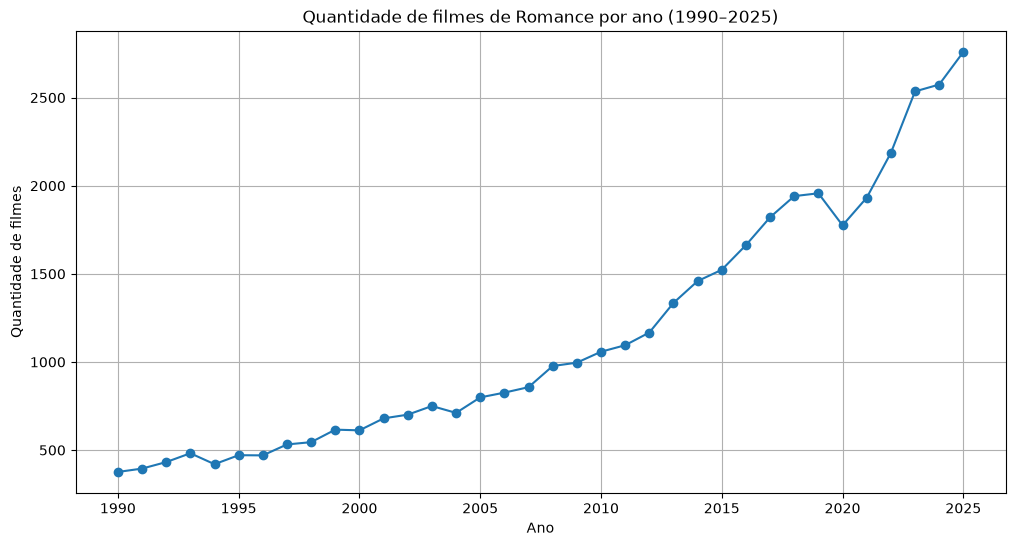

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df_filmes_ano["ano"],
    df_filmes_ano["quantidade"],
    marker="o"
)

plt.title(
    "Quantidade de filmes de Romance por ano (1990–2025)"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de filmes")

plt.grid(True)

plt.show()

# 💭 Dedução da primeira hipótese:

O número absoluto de filmes de Romance teve um aumento bastante considerável.

Fazendo a comparação de 1990 com 2025:

- **1990: 376 filmes de Romance**

- **2025: 2.759 filmes de Romance**

Entretanto, isso não significa que a gênero "Romance" teve um aumento de popularidade 7x maior em
relação aos anos 90, pois o número total de filmes registrados no TMDB também aumentou muito:

- **1990: 7.252 filmes**

- **2025: 53.715 filmes**

___

# Segunda hipótese: Quantos porcento dos filmes lançados em cada ano eram do gênero Romance?

In [12]:
df_filmes_ano["decada"] = (df_filmes_ano["ano"] // 10) * 10

df_filmes_ano

,ano,quantidade,decada
0,1990,376,1990
1,1991,395,1990
2,1992,432,1990
3,1993,482,1990
4,1994,420,1990
5,1995,471,1990
6,1996,470,1990
7,1997,532,1990
8,1998,545,1990
9,1999,616,1990


In [13]:
filmes_por_decada = (
    df_filmes_ano
    .groupby("decada")["quantidade"]
    .sum()
    .reset_index()
)

filmes_por_decada

,decada,quantidade
0,1990,4739
1,2000,7909
2,2010,15019
3,2020,13761


In [ ]:
import requests
import pandas as pd
import time

url_discover = "https://api.themoviedb.org/3/discover/movie"

resultados_total = []

for ano in range(1990, 2026):

    parametros_ano = {
        "api_key": api_key,
        "language": "pt-BR",
        "primary_release_date.gte": f"{ano}-01-01",
        "primary_release_date.lte": f"{ano}-12-31",
        "page": 1
    }

    resposta = requests.get(
        url_discover,
        params=parametros_ano
    )

    if resposta.status_code == 200:

        dados = resposta.json()

        # guarda o ano e a quantidade total de filmes
        resultados_total.append({
            "ano": ano,
            "total_filmes": dados["total_results"]
        })

        print(
            f"{ano}: {dados['total_results']} filmes no total"
        )

    else:
        print(
            f"Erro no ano {ano}: {resposta.status_code}"
        )

    time.sleep(0.1)

df_total = pd.DataFrame(resultados_total)

df_total

1990: 7252 filmes no total
1991: 7332 filmes no total
1992: 7294 filmes no total
1993: 7134 filmes no total
1994: 7011 filmes no total
1995: 7230 filmes no total
1996: 7208 filmes no total
1997: 7702 filmes no total
1998: 7834 filmes no total
1999: 8375 filmes no total
2000: 8588 filmes no total
2001: 9299 filmes no total
2002: 10154 filmes no total
2003: 11337 filmes no total
2004: 12395 filmes no total
2005: 13541 filmes no total
2006: 14970 filmes no total
2007: 15526 filmes no total
2008: 16389 filmes no total
2009: 17256 filmes no total
2010: 17920 filmes no total
2011: 19447 filmes no total
2012: 21174 filmes no total
2013: 23632 filmes no total
2014: 25273 filmes no total
2015: 26601 filmes no total
2016: 28105 filmes no total
2017: 31603 filmes no total
2018: 33898 filmes no total
2019: 37174 filmes no total
2020: 37171 filmes no total
2021: 40677 filmes no total
2022: 43159 filmes no total
2023: 49400 filmes no total
2024: 53658 filmes no total
2025: 53715 filmes no total


,ano,total_filmes
0,1990,7252
1,1991,7332
2,1992,7294
3,1993,7134
4,1994,7011
5,1995,7230
6,1996,7208
7,1997,7702
8,1998,7834
9,1999,8375


In [15]:
df_analise = pd.merge(
    df_filmes_ano,
    df_total,
    on="ano"
)

df_analise

,ano,quantidade,decada,total_filmes
0,1990,376,1990,7252
1,1991,395,1990,7332
2,1992,432,1990,7294
3,1993,482,1990,7134
4,1994,420,1990,7011
5,1995,471,1990,7230
6,1996,470,1990,7208
7,1997,532,1990,7702
8,1998,545,1990,7834
9,1999,616,1990,8375


In [16]:
df_analise["percentual_romance"] = (
    df_analise["quantidade"]
    / df_analise["total_filmes"]
) * 100

In [17]:
df_analise

,ano,quantidade,decada,total_filmes,percentual_romance
0,1990,376,1990,7252,5.184777
1,1991,395,1990,7332,5.387343
2,1992,432,1990,7294,5.922676
3,1993,482,1990,7134,6.756378
4,1994,420,1990,7011,5.990586
5,1995,471,1990,7230,6.514523
6,1996,470,1990,7208,6.520533
7,1997,532,1990,7702,6.907297
8,1998,545,1990,7834,6.956855
9,1999,616,1990,8375,7.355224


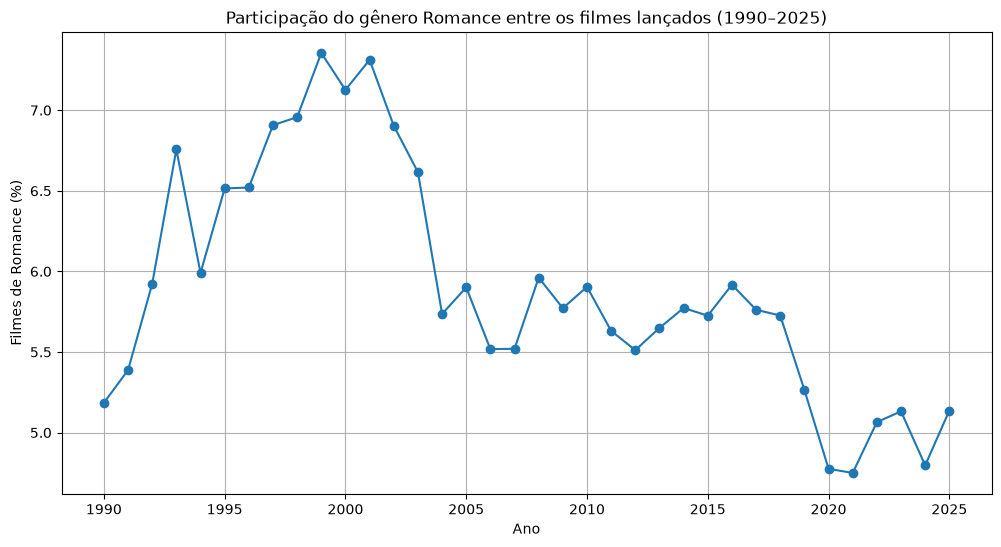

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    df_analise["ano"],
    df_analise["percentual_romance"],
    marker="o"
)

plt.title(
    "Participação do gênero Romance entre os filmes lançados (1990–2025)"
)

plt.xlabel("Ano")
plt.ylabel("Filmes de Romance (%)")

plt.grid(True)

plt.show()

In [19]:
df_analise[
    df_analise["ano"].isin([1990, 2000, 2010, 2020, 2025])
]

,ano,quantidade,decada,total_filmes,percentual_romance
0,1990,376,1990,7252,5.184777
10,2000,612,2000,8588,7.126223
20,2010,1058,2010,17920,5.904018
30,2020,1775,2020,37171,4.775228
35,2025,2759,2020,53715,5.136368


# 💭 Dedução da segunda hipótese:

A porcentagem de filmes de romance lançados em relação ao total de filmes lançados 
em cada década, segundo a análise dos nossos dados:

### **Década de 1990**:
A participação do Romance aumentou de: **5,18% -> 7,36%**

### **Década de 2000**: 
O percentual caiu de aproximadamente: **7,13% -> 5,77%**

O romance começa a perder a participação.

### **Década de 2010**:
O percentual ficou relativamente estável, variando aproximadamente entre: **5,26% e 5,90%**

### **Década de 2020-2025**:
O gênero chegou a: **4,78%** em 2020

E terminou em: **5,14%** em 2025

##### Em suma, houve uma pequena recuperação, mas o percentual continua abaixo dos níveis observados no final dos anos 1990.
